Section 1 Setup and Dataset Loading

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import time
import random

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Section 2 — Dataset Normalization and Loading

In [2]:
# Normalize grayscale images

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 252kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.34MB/s]

Train Dataset Size: 60000
Test Dataset Size: 10000


Section 3 — Dataset Shape Explanation

In [3]:

sample_image, sample_label = train_dataset[0]

print("Image Tensor Shape:", sample_image.shape)
print("Label:", sample_label)

# Shape explanation
# [1, 28, 28]
# 1 -> grayscale channel
# 28 -> image height
# 28 -> image width

Image Tensor Shape: torch.Size([1, 28, 28])
Label: 9


Section 4 — Display Five Random Images

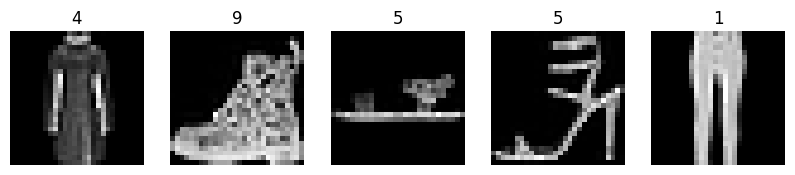

In [4]:

plt.figure(figsize=(10,4))

for i in range(5):

    idx = random.randint(0, len(train_dataset))

    img, label = train_dataset[idx]

    plt.subplot(1,5,i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.show()

Section 5 — Helper Functions

In [5]:

def train_model(model, optimizer, train_loader, val_loader, epochs=10):

    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for X, y in train_loader:

            X, y = X.to(device), y.to(device)

            X = X.view(X.size(0), -1)

            optimizer.zero_grad()

            output = model(X)

            loss = F.cross_entropy(output, y)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)


        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():

            for X, y in val_loader:

                X, y = X.to(device), y.to(device)
                X = X.view(X.size(0), -1)

                output = model(X)

                loss = F.cross_entropy(output, y)

                val_loss += loss.item()

                preds = output.argmax(dim=1)

                correct += (preds == y).sum().item()

        val_loss = val_loss / len(val_loader)
        acc = 100 * correct / len(val_loader.dataset)

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Acc {acc:.2f}%")

    end_time = time.time()

    training_time = end_time - start_time

    return train_losses, val_losses, acc, training_time

Section 6 — Plot Loss Function

In [6]:

def plot_losses(train_losses, val_losses, title):

    plt.figure(figsize=(6,4))

    plt.plot(train_losses,label="Train Loss")
    plt.plot(val_losses,label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)

    plt.legend()
    plt.show()

Section 7 — Parameter Counter

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Section 8 — Flexible MLP Architecture

In [8]:
class MLP(nn.Module):

    def __init__(self, layers):
        super().__init__()

        self.layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]
        )

    def forward(self,x):

        for layer in self.layers[:-1]:
            x = F.relu(layer(x))

        return self.layers[-1](x)

Section 9 — Architecture Experiment Models

In [9]:
model_A = MLP([784,32,10]).to(device)
model_B = MLP([784,128,64,10]).to(device)
model_C = MLP([784,256,128,64,10]).to(device)


Section 10 — Train Model A

Epoch 1 | Train Loss 0.5568 | Val Loss 0.4693 | Acc 83.36%
Epoch 2 | Train Loss 0.4241 | Val Loss 0.4376 | Acc 84.39%
Epoch 3 | Train Loss 0.3919 | Val Loss 0.4399 | Acc 84.25%
Epoch 4 | Train Loss 0.3693 | Val Loss 0.4107 | Acc 84.93%
Epoch 5 | Train Loss 0.3546 | Val Loss 0.3907 | Acc 86.10%
Epoch 6 | Train Loss 0.3417 | Val Loss 0.3876 | Acc 86.26%
Epoch 7 | Train Loss 0.3306 | Val Loss 0.3870 | Acc 86.57%
Epoch 8 | Train Loss 0.3210 | Val Loss 0.3927 | Acc 85.66%
Epoch 9 | Train Loss 0.3115 | Val Loss 0.3806 | Acc 86.14%
Epoch 10 | Train Loss 0.3054 | Val Loss 0.3741 | Acc 86.64%


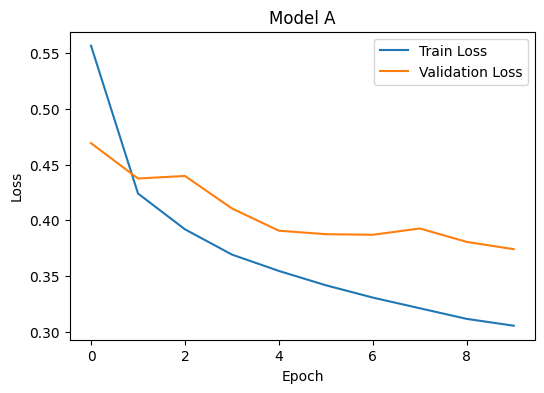

In [10]:
opt = optim.Adam(model_A.parameters(), lr=1e-3)

trA, vaA, accA, timeA = train_model(model_A, opt, train_loader, test_loader, epochs=10)

paramsA = count_parameters(model_A)

plot_losses(trA,vaA,"Model A")

Section 11 — Train Model B

Epoch 1 | Train Loss 0.5202 | Val Loss 0.4349 | Acc 84.35%
Epoch 2 | Train Loss 0.3805 | Val Loss 0.4341 | Acc 84.28%
Epoch 3 | Train Loss 0.3401 | Val Loss 0.3756 | Acc 86.37%
Epoch 4 | Train Loss 0.3138 | Val Loss 0.3877 | Acc 86.09%
Epoch 5 | Train Loss 0.2955 | Val Loss 0.3437 | Acc 87.81%
Epoch 6 | Train Loss 0.2835 | Val Loss 0.3592 | Acc 87.19%
Epoch 7 | Train Loss 0.2686 | Val Loss 0.3531 | Acc 87.27%
Epoch 8 | Train Loss 0.2567 | Val Loss 0.3511 | Acc 87.87%
Epoch 9 | Train Loss 0.2476 | Val Loss 0.3390 | Acc 88.14%
Epoch 10 | Train Loss 0.2359 | Val Loss 0.3382 | Acc 88.44%


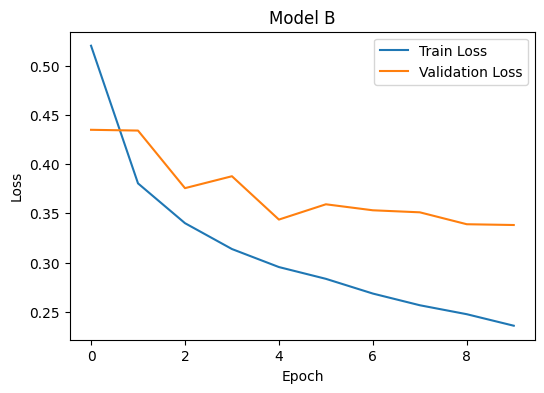

In [11]:
opt = optim.Adam(model_B.parameters(), lr=1e-3)

trB, vaB, accB, timeB = train_model(model_B, opt, train_loader, test_loader, epochs=10)

paramsB = count_parameters(model_B)

plot_losses(trB,vaB,"Model B")

Section 12 — Train Model C

Epoch 1 | Train Loss 0.5249 | Val Loss 0.4414 | Acc 83.81%
Epoch 2 | Train Loss 0.3756 | Val Loss 0.3771 | Acc 86.14%
Epoch 3 | Train Loss 0.3364 | Val Loss 0.3973 | Acc 85.42%
Epoch 4 | Train Loss 0.3127 | Val Loss 0.3535 | Acc 87.33%
Epoch 5 | Train Loss 0.2931 | Val Loss 0.3489 | Acc 87.44%
Epoch 6 | Train Loss 0.2778 | Val Loss 0.3591 | Acc 87.30%
Epoch 7 | Train Loss 0.2634 | Val Loss 0.3316 | Acc 88.36%
Epoch 8 | Train Loss 0.2545 | Val Loss 0.3817 | Acc 86.46%
Epoch 9 | Train Loss 0.2395 | Val Loss 0.3195 | Acc 88.99%
Epoch 10 | Train Loss 0.2287 | Val Loss 0.3504 | Acc 87.52%


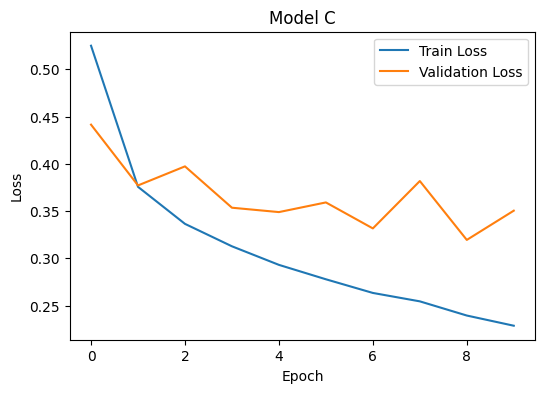

In [12]:
opt = optim.Adam(model_C.parameters(), lr=1e-3)

trC, vaC, accC, timeC = train_model(model_C, opt, train_loader, test_loader, epochs=10)

paramsC = count_parameters(model_C)

plot_losses(trC,vaC,"Model C")

Section 13 — Underfitting vs Overfitting

Epoch 1 | Train Loss 1.0760 | Val Loss 0.7479 | Acc 72.24%
Epoch 2 | Train Loss 0.6738 | Val Loss 0.6610 | Acc 75.73%
Epoch 3 | Train Loss 0.6311 | Val Loss 0.6368 | Acc 76.72%
Epoch 4 | Train Loss 0.6110 | Val Loss 0.6252 | Acc 77.61%
Epoch 5 | Train Loss 0.5986 | Val Loss 0.6218 | Acc 77.73%
Epoch 6 | Train Loss 0.5894 | Val Loss 0.6139 | Acc 77.82%
Epoch 7 | Train Loss 0.5815 | Val Loss 0.6007 | Acc 78.62%
Epoch 8 | Train Loss 0.5753 | Val Loss 0.5996 | Acc 78.50%
Epoch 9 | Train Loss 0.5699 | Val Loss 0.5917 | Acc 79.05%
Epoch 10 | Train Loss 0.5659 | Val Loss 0.5898 | Acc 79.30%


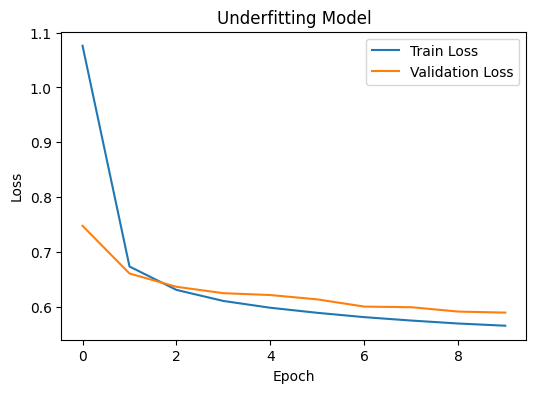

Epoch 1 | Train Loss 0.5944 | Val Loss 0.4958 | Acc 82.30%
Epoch 2 | Train Loss 0.4114 | Val Loss 0.4157 | Acc 85.47%
Epoch 3 | Train Loss 0.3624 | Val Loss 0.3857 | Acc 86.26%
Epoch 4 | Train Loss 0.3329 | Val Loss 0.3704 | Acc 87.13%
Epoch 5 | Train Loss 0.3134 | Val Loss 0.3747 | Acc 87.10%
Epoch 6 | Train Loss 0.2896 | Val Loss 0.3788 | Acc 86.96%
Epoch 7 | Train Loss 0.2802 | Val Loss 0.3776 | Acc 87.01%
Epoch 8 | Train Loss 0.2628 | Val Loss 0.3354 | Acc 87.93%
Epoch 9 | Train Loss 0.2517 | Val Loss 0.3756 | Acc 87.34%
Epoch 10 | Train Loss 0.2421 | Val Loss 0.3806 | Acc 87.85%


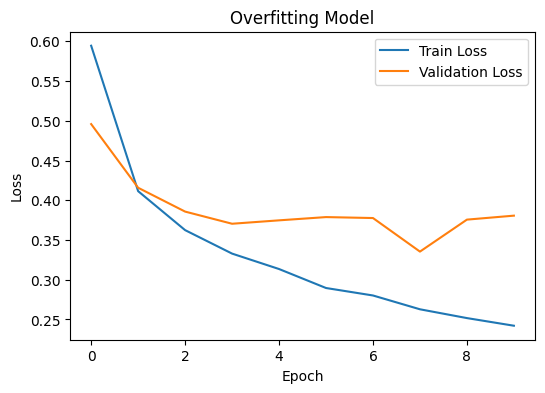

In [13]:

small_model = MLP([784,4,10]).to(device)

opt = optim.Adam(small_model.parameters(),lr=1e-3)

trS,vaS,accS,timeS = train_model(small_model,opt,train_loader,test_loader,epochs=10)

plot_losses(trS,vaS,"Underfitting Model")


large_model = MLP([784,1024,512,512,256,128,64,10]).to(device)

opt = optim.Adam(large_model.parameters(),lr=1e-3)

trL,vaL,accL,timeL = train_model(large_model,opt,train_loader,test_loader,epochs=10)

plot_losses(trL,vaL,"Overfitting Model")

Section 14 — Batch Normalization Model

In [14]:

class MLPBatchNorm(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784,256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256,128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128,64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64,10)


    def forward(self,x):

        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))

        return self.fc4(x)

Section 15 — Train BatchNorm Model

Epoch 1 | Train Loss 0.4786 | Val Loss 0.4052 | Acc 84.89%
Epoch 2 | Train Loss 0.3422 | Val Loss 0.3607 | Acc 87.12%
Epoch 3 | Train Loss 0.3088 | Val Loss 0.3342 | Acc 87.86%
Epoch 4 | Train Loss 0.2809 | Val Loss 0.3343 | Acc 87.85%
Epoch 5 | Train Loss 0.2626 | Val Loss 0.3200 | Acc 88.45%
Epoch 6 | Train Loss 0.2436 | Val Loss 0.3220 | Acc 88.33%
Epoch 7 | Train Loss 0.2309 | Val Loss 0.3102 | Acc 88.86%
Epoch 8 | Train Loss 0.2161 | Val Loss 0.3153 | Acc 89.17%
Epoch 9 | Train Loss 0.2060 | Val Loss 0.3278 | Acc 88.92%
Epoch 10 | Train Loss 0.1935 | Val Loss 0.3267 | Acc 88.67%


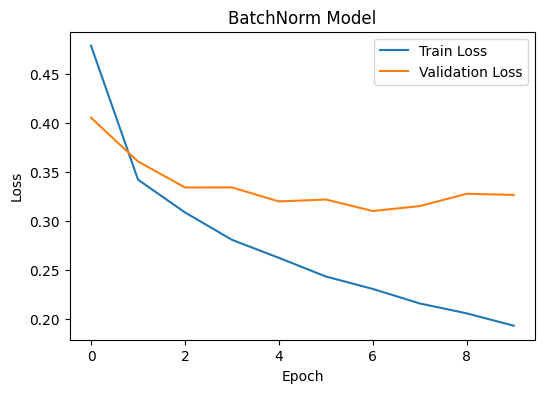

In [15]:
model_bn = MLPBatchNorm().to(device)

opt = optim.Adam(model_bn.parameters(),lr=1e-3)

trBN,vaBN,accBN,timeBN = train_model(model_bn,opt,train_loader,test_loader,epochs=10)

paramsBN = count_parameters(model_bn)

plot_losses(trBN,vaBN,"BatchNorm Model")

Section 16 — Confusion Matrix

In [16]:

def compute_confusion_matrix(model,loader,num_classes=10):

    cm = np.zeros((num_classes,num_classes),dtype=int)

    model.eval()

    with torch.no_grad():

        for X,y in loader:

            X = X.to(device)

            out = model(X.view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu().numpy()

            y_np = y.numpy()

            for t,p in zip(y_np,preds):
                cm[t,p] += 1

    return cm

In [17]:

def plot_confusion_matrix(cm):

    plt.figure(figsize=(6,6))

    plt.imshow(cm)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,str(cm[i,j]),ha="center",va="center")

    plt.colorbar()

    plt.show()

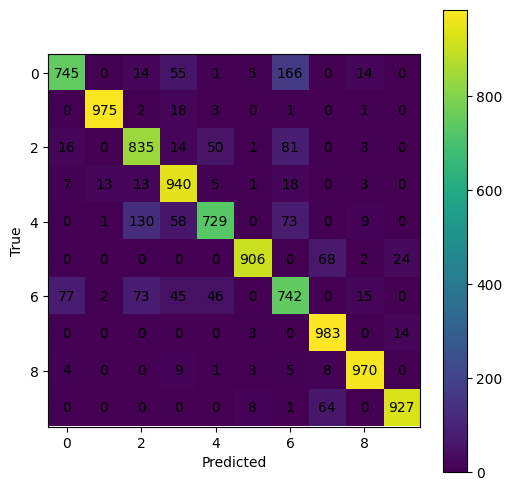

In [18]:
cm = compute_confusion_matrix(model_C,test_loader)

plot_confusion_matrix(cm)

Section 17 — Misclassified Images

In [19]:

def show_misclassified(model,loader,n=10):

    model.eval()

    wrong=[]

    with torch.no_grad():

        for X,y in loader:

            out = model(X.to(device).view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu()

            for i in range(len(y)):

                if preds[i] != y[i]:

                    wrong.append((X[i].squeeze(),preds[i].item(),y[i].item()))

                if len(wrong) >= n:
                    break

            if len(wrong) >= n:
                break

    plt.figure(figsize=(12,3))

    for i,(img,pred,true) in enumerate(wrong):

        plt.subplot(1,n,i+1)

        plt.imshow(img,cmap="gray")

        plt.title(f"P:{pred} T:{true}")

        plt.axis("off")

    plt.show()


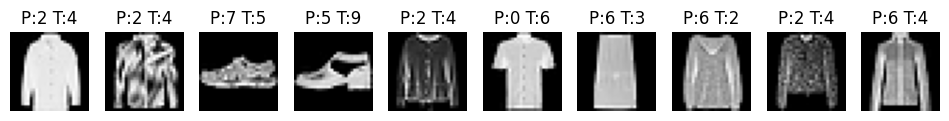

In [20]:
show_misclassified(model_C,test_loader,10)

Section 18 — Model Comparison Table

In [21]:
print("Model Comparison\n")

print("Model A | Params:",paramsA,"| Accuracy:",accA,"| Time:",timeA)
print("Model B | Params:",paramsB,"| Accuracy:",accB,"| Time:",timeB)
print("Model C | Params:",paramsC,"| Accuracy:",accC,"| Time:",timeC)
print("Small Model | Params:",count_parameters(small_model),"| Accuracy:",accS,"| Time:",timeS)
print("Large Model | Params:",count_parameters(large_model),"| Accuracy:",accL,"| Time:",timeL)
print("BatchNorm Model | Params:",paramsBN,"| Accuracy:",accBN,"| Time:",timeBN)

Model Comparison

Model A | Params: 25450 | Accuracy: 86.64 | Time: 175.8430917263031
Model B | Params: 109386 | Accuracy: 88.44 | Time: 186.81720161437988
Model C | Params: 242762 | Accuracy: 87.52 | Time: 207.78628039360046
Small Model | Params: 3190 | Accuracy: 79.3 | Time: 169.23076701164246
Large Model | Params: 1764426 | Accuracy: 87.85 | Time: 538.0924205780029
BatchNorm Model | Params: 243658 | Accuracy: 88.67 | Time: 205.47913599014282
